# STICS Successive Converter - Test Run

This notebook runs the STICS successive converter. Simulations are grouped from `SimUnitList` by `idPoint`, `idMangt`, and `idOption`, ordered by `StartYear`, then chained with `recup.tmp`.

## 1. Locate the Repository and Import Modules

In [1]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
repo_root = next(
    (
        path
        for path in candidates
        if (path / "tests" / "data").exists() and (path / "src" / "modfilegen").exists()
    ),
    None,
)
if repo_root is None:
    raise FileNotFoundError(f"Could not locate the ModFileGen repository from cwd={cwd}.")

src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from modfilegen import GlobalVariables
from modfilegen.Converter.SticsConverter.sticssuccessiveconverter import (
    adapt_group_calendar,
    build_successive_groups,
    main,
)
from modfilegen.Converter.SticsConverter.sticsconverter import fetch_data_from_sqlite

print(f"Kernel cwd: {cwd}")
print(f"Repo root: {repo_root}")

Kernel cwd: /mnt/d/Mes Donnees/TCMP/github/ModFileGen/notebooks
Repo root: /mnt/d/Mes Donnees/TCMP/github/ModFileGen


## 2. Configure Paths

In [2]:
data_dir = repo_root / "tests" / "data"
output_dir = repo_root / "tests" / "output_successive"
temp_dir = output_dir / "temp"
package_dir = repo_root / "src" / "modfilegen"

master_input_db = data_dir / "MasterInput.db"
models_dict_db = data_dir / "ModelsDictionaryArise.db"
cultivars_folder = data_dir / "cultivars" / "stics"

output_dir.mkdir(parents=True, exist_ok=True)
temp_dir.mkdir(parents=True, exist_ok=True)

n_threads = 4
dt = 0

print(f"Master Input DB exists: {master_input_db.exists()} -> {master_input_db}")
print(f"Models Dict DB exists: {models_dict_db.exists()} -> {models_dict_db}")
print(f"Cultivars folder exists: {cultivars_folder.exists()} -> {cultivars_folder}")
print(f"Output directory: {output_dir}")
print(f"Temp directory: {temp_dir}")

Master Input DB exists: True -> /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/data/MasterInput.db
Models Dict DB exists: True -> /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/data/ModelsDictionaryArise.db
Cultivars folder exists: True -> /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/data/cultivars/stics
Output directory: /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/output_successive
Temp directory: /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/output_successive/temp


## 3. Preview Successive Groups

This checks how simulations will be grouped and how dates will be adapted before running STICS.

In [3]:
rows = fetch_data_from_sqlite(str(master_input_db))
groups = build_successive_groups(rows)

print(f"Total simulations: {len(rows)}")
print(f"Successive groups: {len(groups)}")

for group_index, group in enumerate(groups[:5], start=1):
    adapted = adapt_group_calendar(group)
    key = (adapted[0]["idPoint"], adapted[0]["idMangt"], adapted[0]["idOption"])
    print(f"\nGroup {group_index}: {key}")
    for row in adapted[:5]:
        print(
            f"  {row['idsim']}: "
            f"start={row['StartYear']}-{row['StartDay']} "
            f"end={row['EndYear']}-{row['EndDay']}"
        )

Total simulations: 9
Successive groups: 3

Group 1: ('5.925_6.025', 'Mgt1M0_135', 2)
  5.925_6.025_2000_Mgt1M0_135_2: start=2000-105 end=2000-335
  5.925_6.025_2001_Mgt1M0_135_2: start=2001-105 end=2001-335
  5.925_6.025_2002_Mgt1M0_135_2: start=2002-105 end=2002-335

Group 2: ('5.925_6.025', 'Mgt1M0_150', 2)
  5.925_6.025_2000_Mgt1M0_150_2: start=2000-120 end=2000-350
  5.925_6.025_2001_Mgt1M0_150_2: start=2001-120 end=2001-350
  5.925_6.025_2002_Mgt1M0_150_2: start=2002-120 end=2002-350

Group 3: ('5.925_6.025', 'Mgt1M0_155', 2)
  5.925_6.025_2000_Mgt1M0_155_2: start=2000-125 end=2000-355
  5.925_6.025_2001_Mgt1M0_155_2: start=2001-125 end=2001-355
  5.925_6.025_2002_Mgt1M0_155_2: start=2002-125 end=2002-355


## 4. Set Global Variables

In [4]:
GlobalVariables["dbMasterInput"] = str(master_input_db)
GlobalVariables["dbModelsDictionary"] = str(models_dict_db)
GlobalVariables["directorypath"] = str(output_dir)
GlobalVariables["pltfolder"] = str(cultivars_folder)
GlobalVariables["nthreads"] = n_threads
GlobalVariables["dt"] = dt
GlobalVariables["parts"] = 1
GlobalVariables["tempDir"] = str(temp_dir)
GlobalVariables["package"] = str(package_dir)

print("GlobalVariables configured:")
for key, value in GlobalVariables.items():
    print(f"  {key}: {value}")

GlobalVariables configured:
  storeNumMinSimu: 0
  storeNumMaxSimu: 0
  storeKeyDataN: 0
  dbMasterInput: /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/data/MasterInput.db
  dbModelsDictionary: /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/data/ModelsDictionaryArise.db
  dbCelsius: 
  dt: 0
  ori_MI: 
  parts: 1
  tempDir: /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/output_successive/temp
  package: /mnt/d/Mes Donnees/TCMP/github/ModFileGen/src/modfilegen
  directorypath: /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/output_successive
  pltfolder: /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/data/cultivars/stics
  nthreads: 4


## 5. Run the Successive STICS Converter

Each group runs sequentially to preserve `recup.tmp`, while independent groups run in parallel.

In [5]:
print("Starting STICS successive conversion...")
print("=" * 60)

result_path = main()

print("=" * 60)
print(f"Result CSV: {result_path}")

Starting STICS successive conversion...
dbMasterInput: /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/data/MasterInput.db
dbModelsDictionary: /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/data/ModelsDictionaryArise.db
Indexes created successfully!
Total simulations to process: 9
Successive groups: 3
Parallel workers: 4
Processing successive group ('5.925_6.025', 'Mgt1M0_135', '2') with 3 simulation(s)Processing successive group ('5.925_6.025', 'Mgt1M0_150', '2') with 3 simulation(s)

Processing successive group ('5.925_6.025', 'Mgt1M0_155', '2') with 3 simulation(s)
Results saved to /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/output_successive/b95f7b52-9642-4a7f-9c88-7bf6b65bc4ef_stics_successive.csv
STICS successive total time: 4.45s
Result CSV: /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/output_successive/b95f7b52-9642-4a7f-9c88-7bf6b65bc4ef_stics_successive.csv


## 6. Check Generated Files

In [15]:
from itertools import islice

csv_files = sorted(output_dir.glob("*_stics_successive.csv"), key=lambda path: path.stat().st_mtime, reverse=True)
print(f"Successive result CSV files: {len(csv_files)}")
for path in csv_files[:5]:
    print(f"  {path.name}")

recup_files = sorted(temp_dir.glob("*/recup.tmp"))
print(f"\nrecup.tmp files: {len(recup_files)}")
for path in islice(recup_files, 5):
    print(f"  {path}")

if result_path:
    import pandas as pd
    result_df = pd.read_csv(result_path)
    print(f"\nRows in result CSV: {len(result_df)}")
    display(result_df.head())

Successive result CSV files: 2
  3dc43a46-f845-465a-a161-8e89f43446f8_stics_successive.csv
  1355e27d-1a48-44c4-9336-a176f0726b13_stics_successive.csv

recup.tmp files: 15
  /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/output_successive/temp/5.925_6.025_2000_Mgt1M0_135_2/recup.tmp
  /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/output_successive/temp/5.925_6.025_2000_Mgt1M0_135_2__intercrop__5.925_6.025_2001_Mgt1M0_135_2/recup.tmp
  /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/output_successive/temp/5.925_6.025_2000_Mgt1M0_150_2/recup.tmp
  /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/output_successive/temp/5.925_6.025_2000_Mgt1M0_150_2__intercrop__5.925_6.025_2001_Mgt1M0_150_2/recup.tmp
  /mnt/d/Mes Donnees/TCMP/github/ModFileGen/tests/output_successive/temp/5.925_6.025_2000_Mgt1M0_155_2/recup.tmp

Rows in result CSV: 9


,Model,Idsim,Texte,index,P_usm,wlieu,ansemis,P_iwater,ancours,ifin,...,irecs,MaxLai,CroN_ma,Nleac,SoilN,CumE,Transp,time,lon,lat
0,Stics,5.925_6.025_2000_Mgt1M0_135_2,NaN,0,maize,cli5,2000,105,2000,262,...,262.0,5.168,50.313,20.985,20.373,176.413,277.265,2000,6.025,5.925
1,Stics,5.925_6.025_2001_Mgt1M0_135_2,NaN,0,maize,cli5,2001,105,2001,262,...,262.0,5.164,43.433,16.998,17.568,21.565,268.451,2001,6.025,5.925
2,Stics,5.925_6.025_2002_Mgt1M0_135_2,NaN,0,maize,cli5,2002,105,2002,261,...,261.0,5.259,51.570,21.922,20.889,4.328,277.136,2002,6.025,5.925
3,Stics,5.925_6.025_2000_Mgt1M0_150_2,NaN,0,maize,cli5,2000,120,2000,279,...,279.0,5.064,49.802,23.106,20.152,180.138,270.663,2000,6.025,5.925
4,Stics,5.925_6.025_2001_Mgt1M0_150_2,NaN,0,maize,cli5,2001,120,2001,279,...,279.0,4.685,44.478,18.889,24.846,23.328,249.089,2001,6.025,5.925


## 7. Verify Succession Continuity

Plot soil state variables to verify that simulations are properly chained via `recup.tmp`. These variables should show **continuous curves** across simulation boundaries.

Found 3 treatment groups

Treatment 1: 5.925_6.025_Mgt1M0_135_2
Directories: 5
  + 5.925_6.025_2000_Mgt1M0_135_2/mod_smaize.sti (231 days)
  + 5.925_6.025_2000_Mgt1M0_135_2__intercrop__5.925_6.025_2001_Mgt1M0_135_2/mod_sbare_soil.sti (135 days)
  + 5.925_6.025_2001_Mgt1M0_135_2/mod_smaize.sti (231 days)
  + 5.925_6.025_2001_Mgt1M0_135_2__intercrop__5.925_6.025_2002_Mgt1M0_135_2/mod_sbare_soil.sti (134 days)
  + 5.925_6.025_2002_Mgt1M0_135_2/mod_smaize.sti (231 days)
  Total days simulated: 962
  Date range: 2000-04-14 00:00:00 to 2002-12-01 00:00:00
  Period transitions: 4


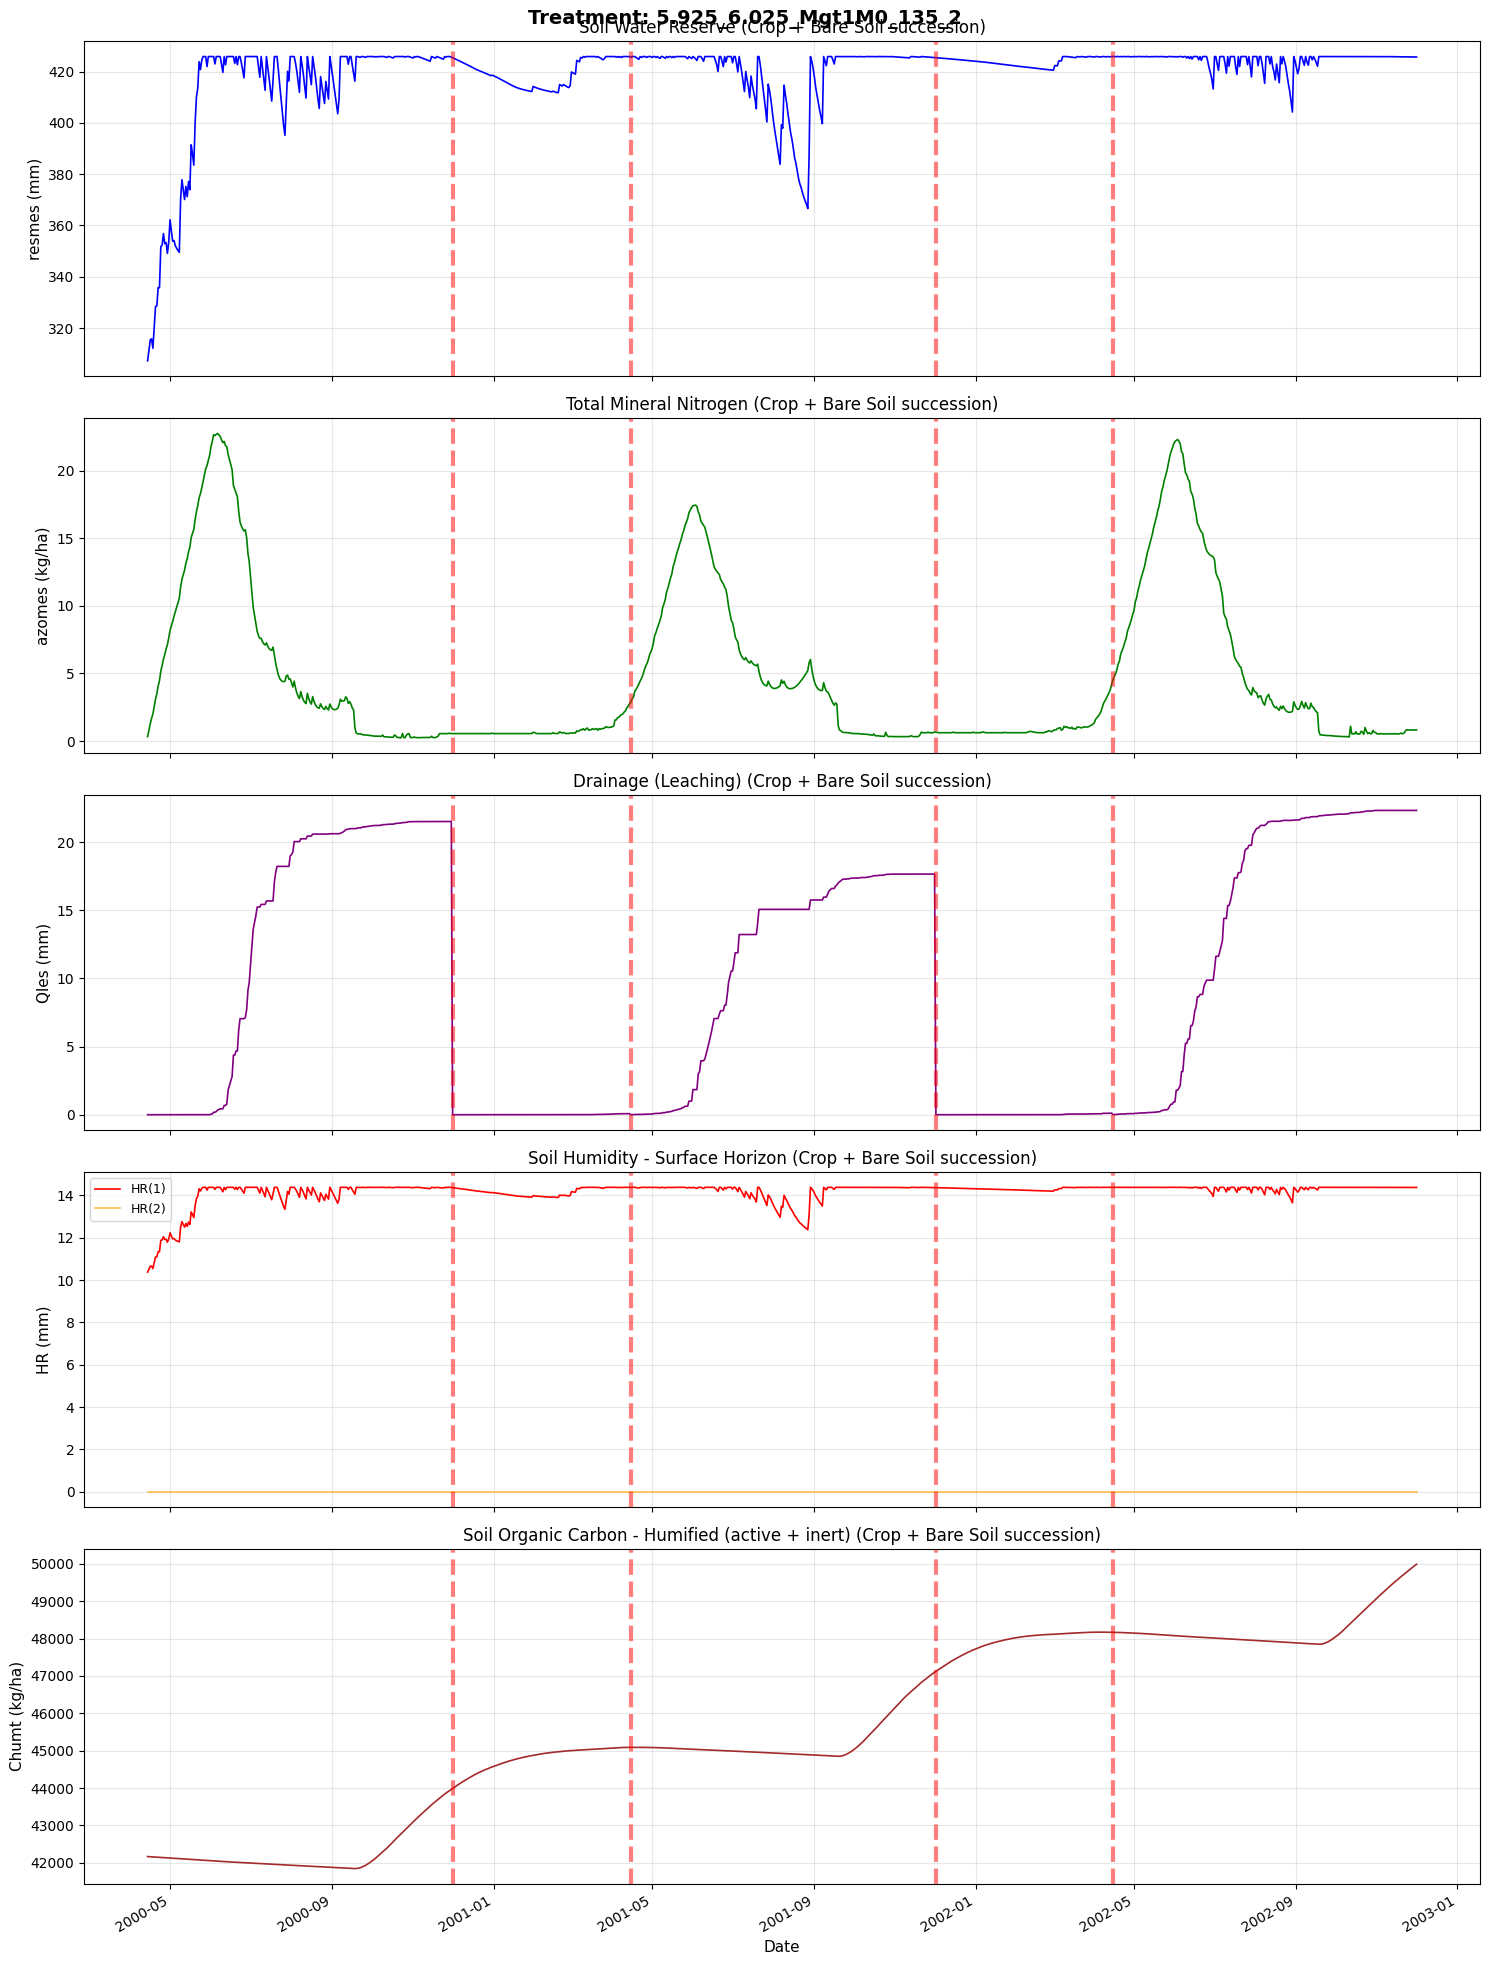

  ✓ Plotted 5 variables

Treatment 2: 5.925_6.025_Mgt1M0_150_2
Directories: 5
  + 5.925_6.025_2000_Mgt1M0_150_2/mod_smaize.sti (231 days)
  + 5.925_6.025_2000_Mgt1M0_150_2__intercrop__5.925_6.025_2001_Mgt1M0_150_2/mod_sbare_soil.sti (135 days)
  + 5.925_6.025_2001_Mgt1M0_150_2/mod_smaize.sti (231 days)
  + 5.925_6.025_2001_Mgt1M0_150_2__intercrop__5.925_6.025_2002_Mgt1M0_150_2/mod_sbare_soil.sti (134 days)
  + 5.925_6.025_2002_Mgt1M0_150_2/mod_smaize.sti (231 days)
  Total days simulated: 962
  Date range: 2000-04-29 00:00:00 to 2002-12-16 00:00:00
  Period transitions: 4


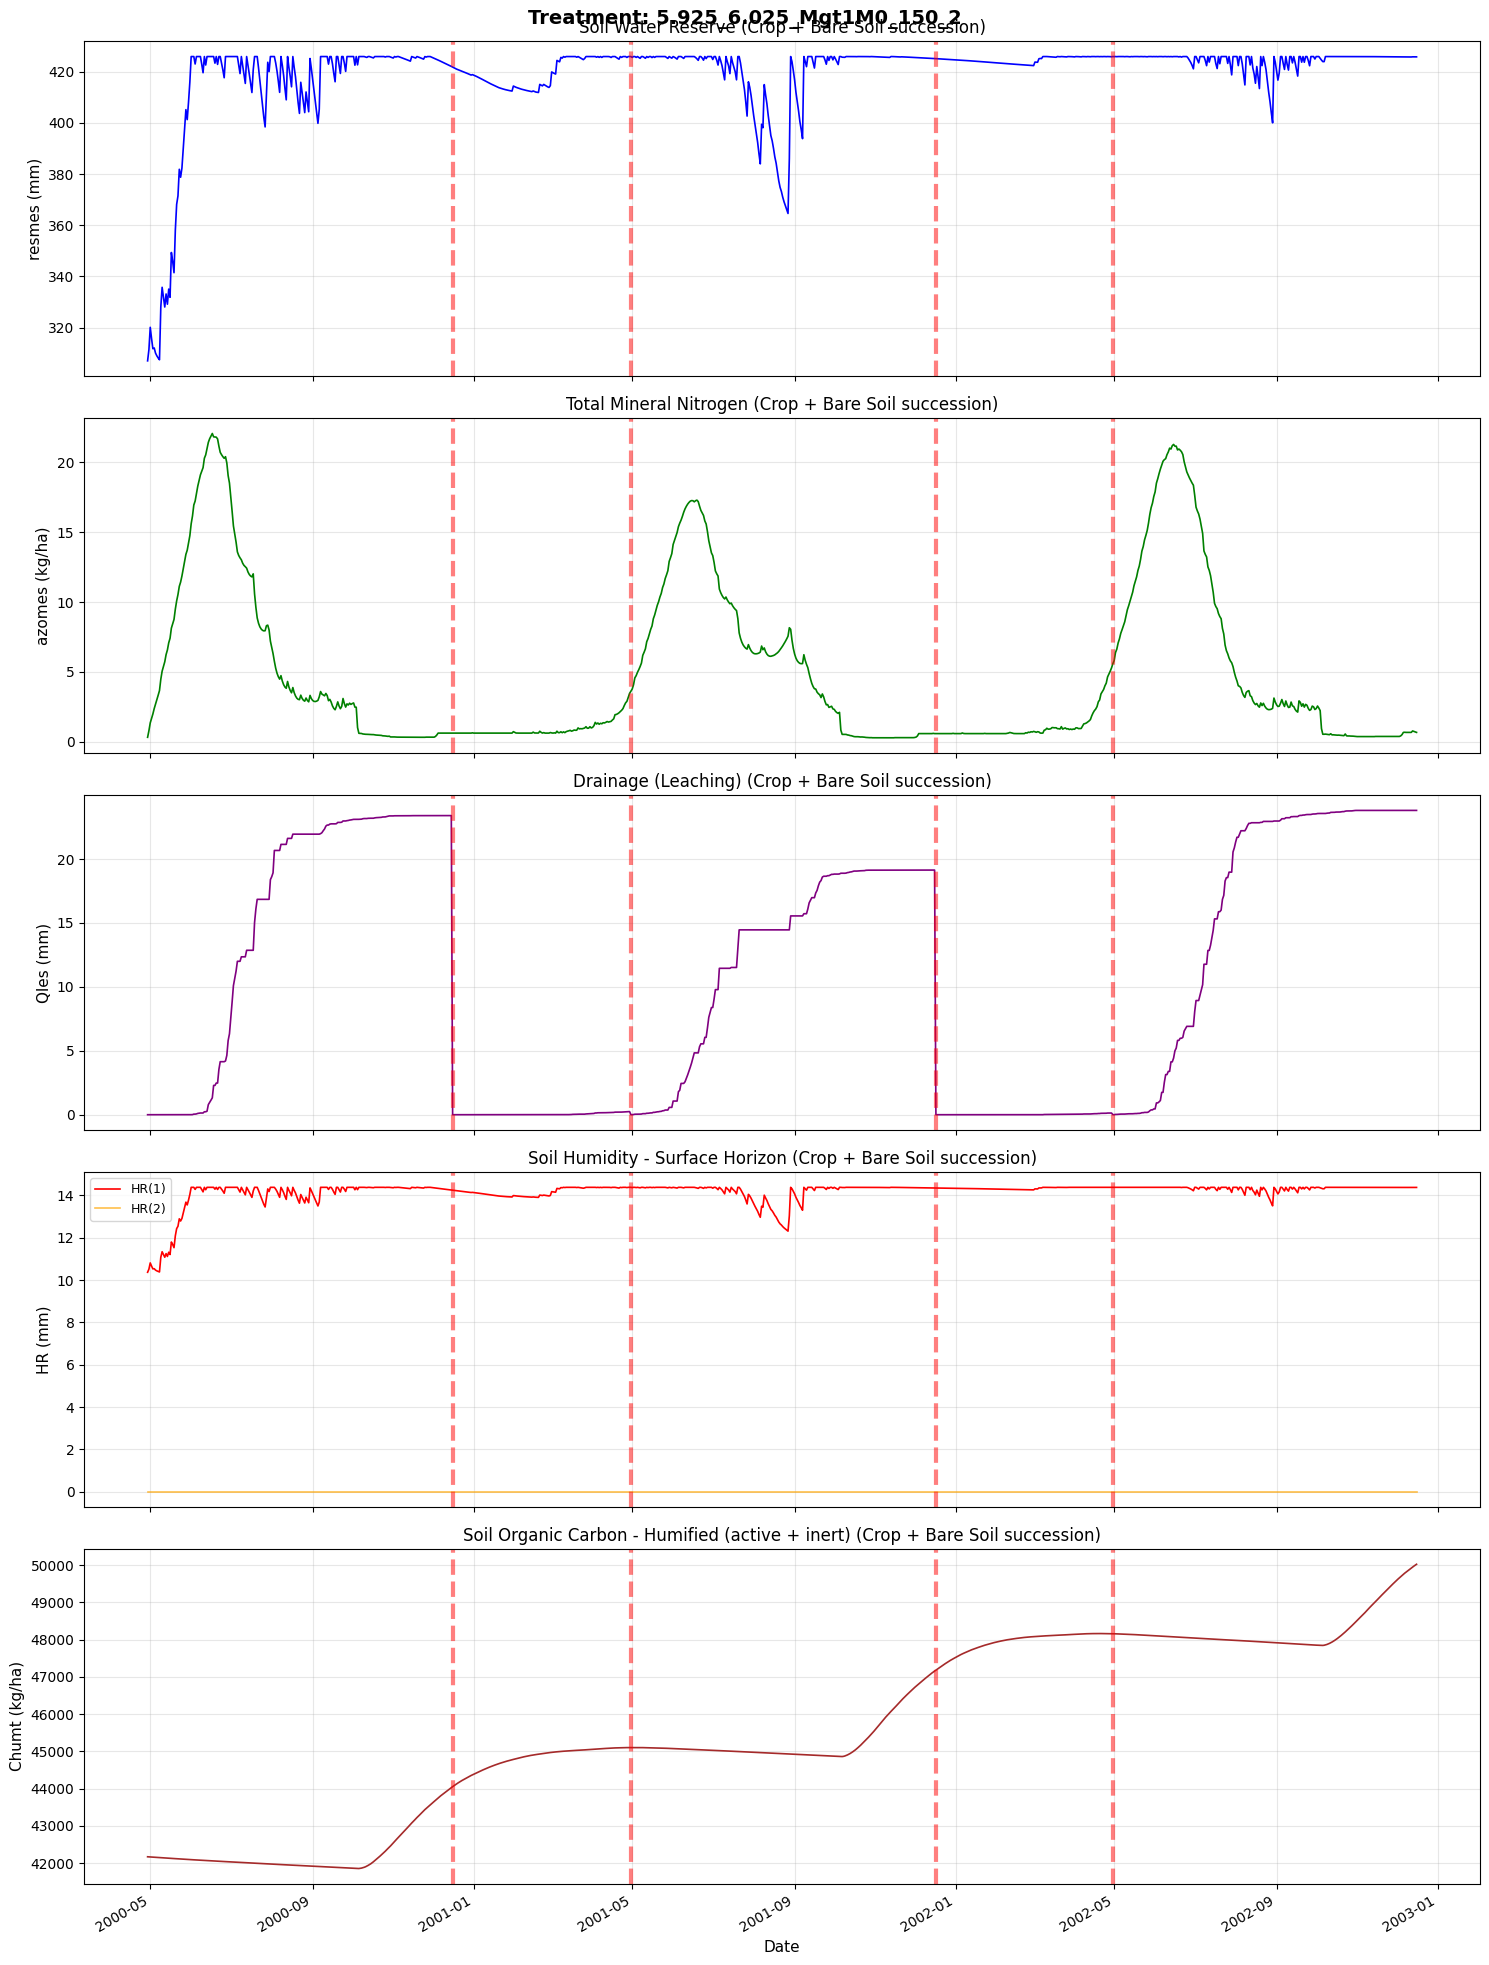

  ✓ Plotted 5 variables

Treatment 3: 5.925_6.025_Mgt1M0_155_2
Directories: 5
  + 5.925_6.025_2000_Mgt1M0_155_2/mod_smaize.sti (231 days)
  + 5.925_6.025_2000_Mgt1M0_155_2__intercrop__5.925_6.025_2001_Mgt1M0_155_2/mod_sbare_soil.sti (135 days)
  + 5.925_6.025_2001_Mgt1M0_155_2/mod_smaize.sti (231 days)
  + 5.925_6.025_2001_Mgt1M0_155_2__intercrop__5.925_6.025_2002_Mgt1M0_155_2/mod_sbare_soil.sti (134 days)
  + 5.925_6.025_2002_Mgt1M0_155_2/mod_smaize.sti (231 days)
  Total days simulated: 962
  Date range: 2000-05-04 00:00:00 to 2002-12-21 00:00:00
  Period transitions: 4


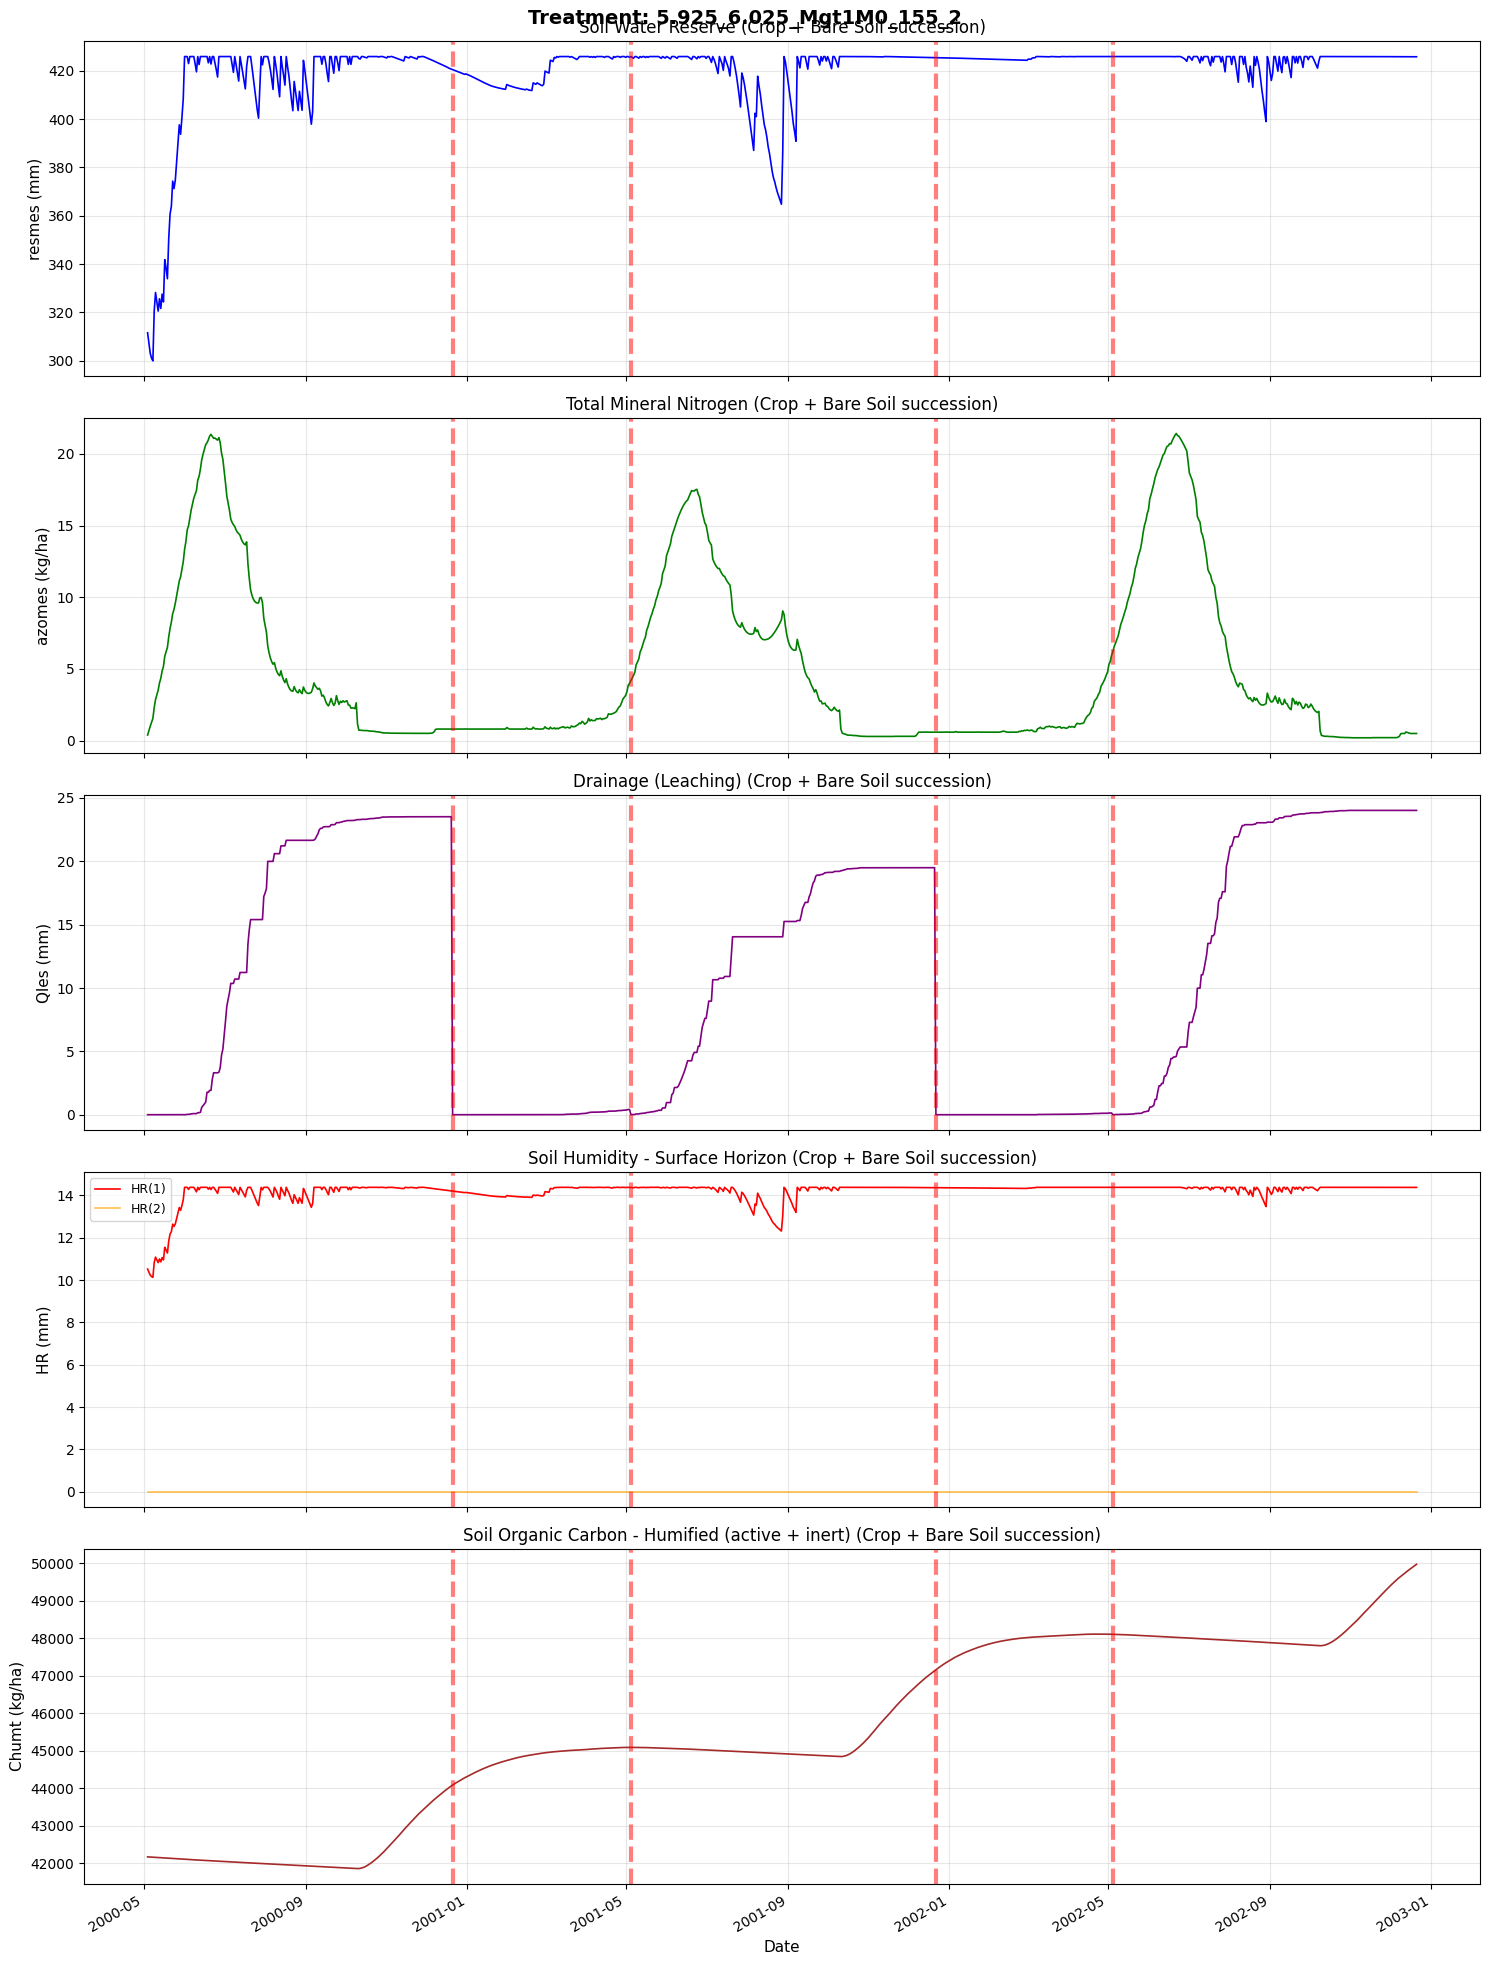

  ✓ Plotted 5 variables

CONTINUITY CHECK PER TREATMENT

Variables plotted: resmes, azomes, Qles, HR(1), Chumt

For proper succession chaining:
  ✓ Bare soil periods show mineralization, drainage, evaporation
  ✓ Each curve shows Crop → Bare Soil → Crop → Bare Soil...
  ✓ NO jumps at transitions (continuous state transfer via recup.tmp)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from collections import defaultdict
import re

# ========================================
# CONFIGURATION: Variables to plot
# ========================================
# Add or remove variables here - each will get its own subplot
VARIABLES_TO_PLOT = [
    {
        'name': 'resmes',
        'ylabel': 'resmes (mm)',
        'title': 'Soil Water Reserve',
        'color': 'blue'
    },
    {
        'name': 'azomes',
        'ylabel': 'azomes (kg/ha)',
        'title': 'Total Mineral Nitrogen',
        'color': 'green'
    },
    {
        'name': 'Qles',
        'ylabel': 'Qles (kg.ha-1)',
        'title': 'Nitrogen Leaching',
        'color': 'purple'
    },
    {
        'name': 'HR(1)',
        'ylabel': 'HR (mm)',
        'title': 'Soil Humidity - Surface Horizon',
        'color': 'red',
        'additional_vars': ['HR(2)']  # Optional: plot multiple variables on same subplot
    },
    {
        'name': 'Chumt',
        'ylabel': 'Chumt (kg/ha)',
        'title': 'Soil Organic Carbon - Humified (active + inert)',
        'color': 'brown'
    }
]

# Number of treatments to display (set to None for all)
MAX_TREATMENTS = 3

# ========================================
# Group simulation directories by treatment
# ========================================
# Pattern: {lat}_{lon}_{year}_Mgt{idMangt}_135_{idOption}
# Intercrop: {sim1}__intercrop__{sim2}

treatment_groups = defaultdict(list)

for sim_dir in sorted(temp_dir.iterdir()):
    if not sim_dir.is_dir():
        continue
    
    dirname = sim_dir.name
    
    # Extract treatment pattern (lat_lon_MgtX_135_Y)
    # Remove year and __intercrop__ parts to get base pattern
    if '__intercrop__' in dirname:
        # For intercrop: extract from first part before __intercrop__
        base_part = dirname.split('__intercrop__')[0]
    else:
        base_part = dirname
    
    # Pattern: lat_lon_year_MgtX_135_Y -> extract lat_lon_MgtX_135_Y
    parts = base_part.split('_')
    if len(parts) >= 5:
        # lat_lon at start, year is 3rd element, then Mgt..._135_Y
        lat_lon = f"{parts[0]}_{parts[1]}"
        # Find Mgt pattern onwards (skipping year which is parts[2])
        mgt_idx = next((i for i, p in enumerate(parts) if p.startswith('Mgt')), None)
        if mgt_idx:
            treatment_pattern = f"{lat_lon}_{'_'.join(parts[mgt_idx:])}"
            treatment_groups[treatment_pattern].append(sim_dir)

print(f"Found {len(treatment_groups)} treatment groups")

# For each treatment, plot the succession
treatment_limit = MAX_TREATMENTS if MAX_TREATMENTS else len(treatment_groups)
for treatment_idx, (treatment_pattern, sim_dirs) in enumerate(list(treatment_groups.items())[:treatment_limit], start=1):
    print(f"\n{'='*60}")
    print(f"Treatment {treatment_idx}: {treatment_pattern}")
    print(f"Directories: {len(sim_dirs)}")
    
    # Sort directories chronologically by extracting year
    def extract_year(sim_dir):
        parts = sim_dir.name.split('_')
        # Year is typically 3rd element
        if len(parts) >= 3:
            try:
                return int(parts[2])
            except ValueError:
                pass
        return 0
    
    sim_dirs_sorted = sorted(sim_dirs, key=extract_year)
    
    # Collect all mod_s*.sti files in chronological order
    treatment_dfs = []
    for sim_dir in sim_dirs_sorted:
        for sti_file in sorted(sim_dir.glob("mod_s*.sti")):
            try:
                df = pd.read_csv(sti_file, sep=";")
                if not df.empty:
                    df['sim_dir'] = sim_dir.name
                    df['is_intercrop'] = '__intercrop__' in sim_dir.name
                    treatment_dfs.append(df)
                    print(f"  + {sim_dir.name}/{sti_file.name} ({len(df)} days)")
            except Exception as e:
                print(f"  ✗ Error reading {sti_file}: {e}")
    
    if not treatment_dfs:
        print("  No data found for this treatment")
        continue
    
    # Combine all outputs in chronological order
    combined_df = pd.concat(treatment_dfs, ignore_index=True)
    
    # Create datetime from ian, mo, jo columns
    if all(col in combined_df.columns for col in ['ian', 'mo', 'jo']):
        combined_df['date'] = pd.to_datetime(
            combined_df[['ian', 'mo', 'jo']].rename(columns={'ian': 'year', 'mo': 'month', 'jo': 'day'})
        )
    else:
        # Fallback: use index if date columns not available
        combined_df['date'] = pd.date_range(start='2000-01-01', periods=len(combined_df), freq='D')
    
    print(f"  Total days simulated: {len(combined_df)}")
    print(f"  Date range: {combined_df['date'].min()} to {combined_df['date'].max()}")
    
    # Detect period transitions (where sim_dir changes)
    transitions = []
    prev_dir = None
    for idx, row in combined_df.iterrows():
        if prev_dir is not None and row['sim_dir'] != prev_dir:
            transitions.append(row['date'])
        prev_dir = row['sim_dir']
    
    print(f"  Period transitions: {len(transitions)}")
    
    # ========================================
    # Create dynamic plots based on configuration
    # ========================================
    
    # Filter variables that exist in the data
    available_vars = [v for v in VARIABLES_TO_PLOT if v['name'] in combined_df.columns]
    
    if not available_vars:
        print("  ⚠ No configured variables found in output files")
        continue
    
    n_plots = len(available_vars)
    fig, axes = plt.subplots(n_plots, 1, figsize=(15, 4*n_plots), sharex=True)
    
    # Handle single plot case (axes is not array)
    if n_plots == 1:
        axes = [axes]
    
    fig.suptitle(f'Treatment: {treatment_pattern}', fontsize=14, fontweight='bold')
    
    # Plot each variable
    for idx, var_config in enumerate(available_vars):
        ax = axes[idx]
        var_name = var_config['name']
        
        # Plot main variable
        ax.plot(combined_df['date'], combined_df[var_name], 
                color=var_config['color'], linewidth=1.2, label=var_name)
        
        # Plot additional variables on same subplot if configured
        if 'additional_vars' in var_config:
            colors_cycle = ['orange', 'brown', 'cyan', 'magenta']
            for add_idx, add_var in enumerate(var_config['additional_vars']):
                if add_var in combined_df.columns:
                    color = colors_cycle[add_idx % len(colors_cycle)]
                    ax.plot(combined_df['date'], combined_df[add_var], 
                            color=color, linewidth=1.2, alpha=0.7, label=add_var)
        
        ax.set_ylabel(var_config['ylabel'], fontsize=11)
        ax.set_title(f"{var_config['title']} (Crop + Bare Soil succession)", fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Add vertical lines at transitions
        for trans_date in transitions:
            ax.axvline(trans_date, color='red', linestyle='--', alpha=0.5, linewidth=3)
        
        # Add legend if multiple variables on this subplot
        if 'additional_vars' in var_config:
            ax.legend(loc='best', fontsize=9)
    
    # Label for x-axis on bottom plot only
    axes[-1].set_xlabel('Date', fontsize=11)
    
    # Format x-axis dates
    fig.autofmt_xdate()
    
    plt.tight_layout()
    plt.show()
    
    print(f"  ✓ Plotted {len(available_vars)} variables")

print("\n" + "="*60)
print("CONTINUITY CHECK PER TREATMENT")

print("="*60)
print(f"\nVariables plotted: {', '.join([v['name'] for v in VARIABLES_TO_PLOT])}")

print("\nFor proper succession chaining:")
print("  ✓ Bare soil periods show mineralization, drainage, evaporation")

print("  ✓ Each curve shows Crop → Bare Soil → Crop → Bare Soil...")
print("  ✓ NO jumps at transitions (continuous state transfer via recup.tmp)")

## 8. Compare Treatments - Same Variable Across All Treatments

Plot each variable with all treatments on the same graph for comparison.

Collected data for 3 treatments

Plotting: resmes - All Treatments Comparison
  ✓ 5.925_6.025_Mgt1M0_135_2: 962 days, 4 transitions
  ✓ 5.925_6.025_Mgt1M0_150_2: 962 days, 4 transitions
  ✓ 5.925_6.025_Mgt1M0_155_2: 962 days, 4 transitions


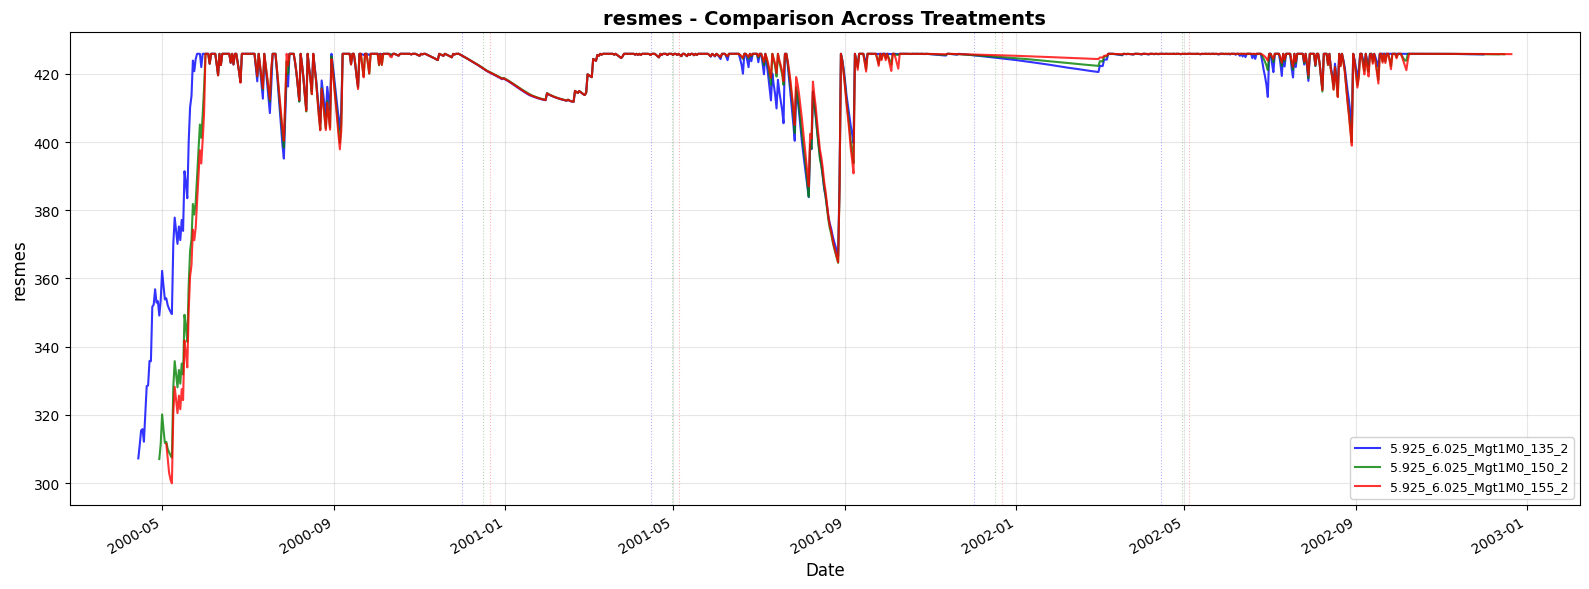


Plotting: azomes - All Treatments Comparison
  ✓ 5.925_6.025_Mgt1M0_135_2: 962 days, 4 transitions
  ✓ 5.925_6.025_Mgt1M0_150_2: 962 days, 4 transitions
  ✓ 5.925_6.025_Mgt1M0_155_2: 962 days, 4 transitions


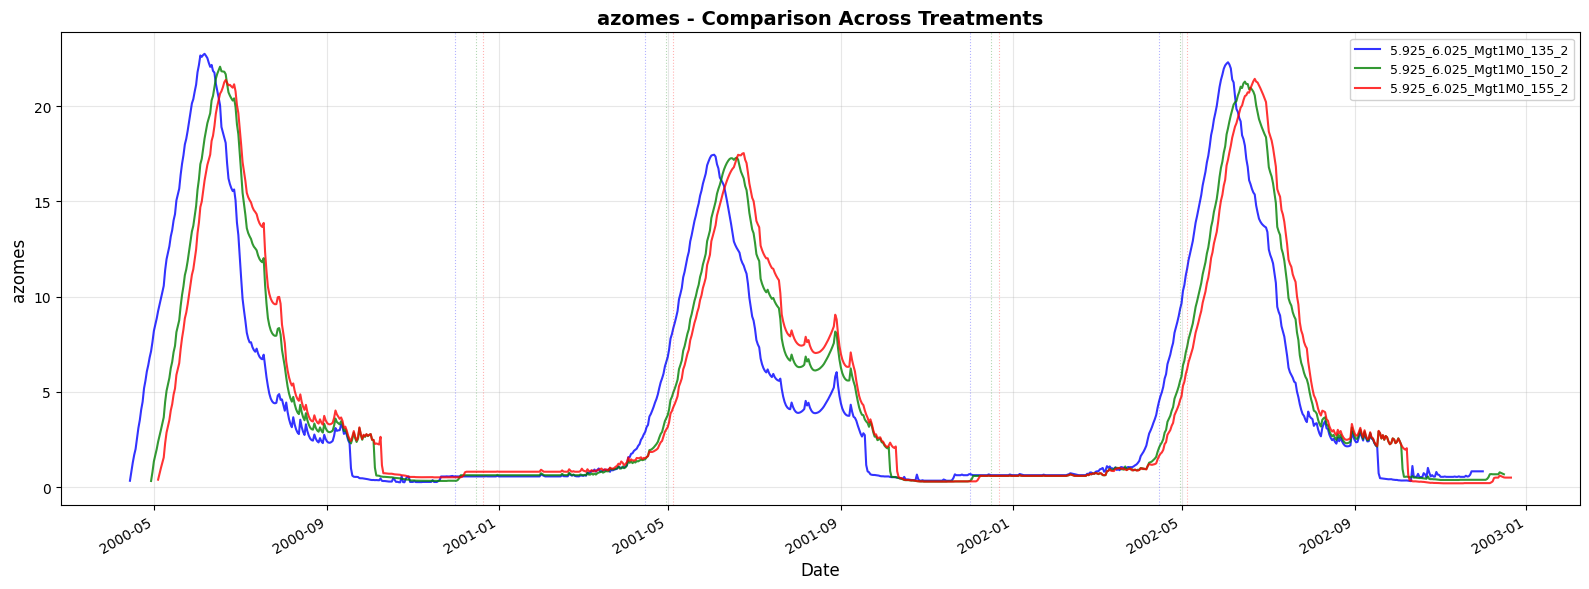


Plotting: Qles - All Treatments Comparison
  ✓ 5.925_6.025_Mgt1M0_135_2: 962 days, 4 transitions
  ✓ 5.925_6.025_Mgt1M0_150_2: 962 days, 4 transitions
  ✓ 5.925_6.025_Mgt1M0_155_2: 962 days, 4 transitions


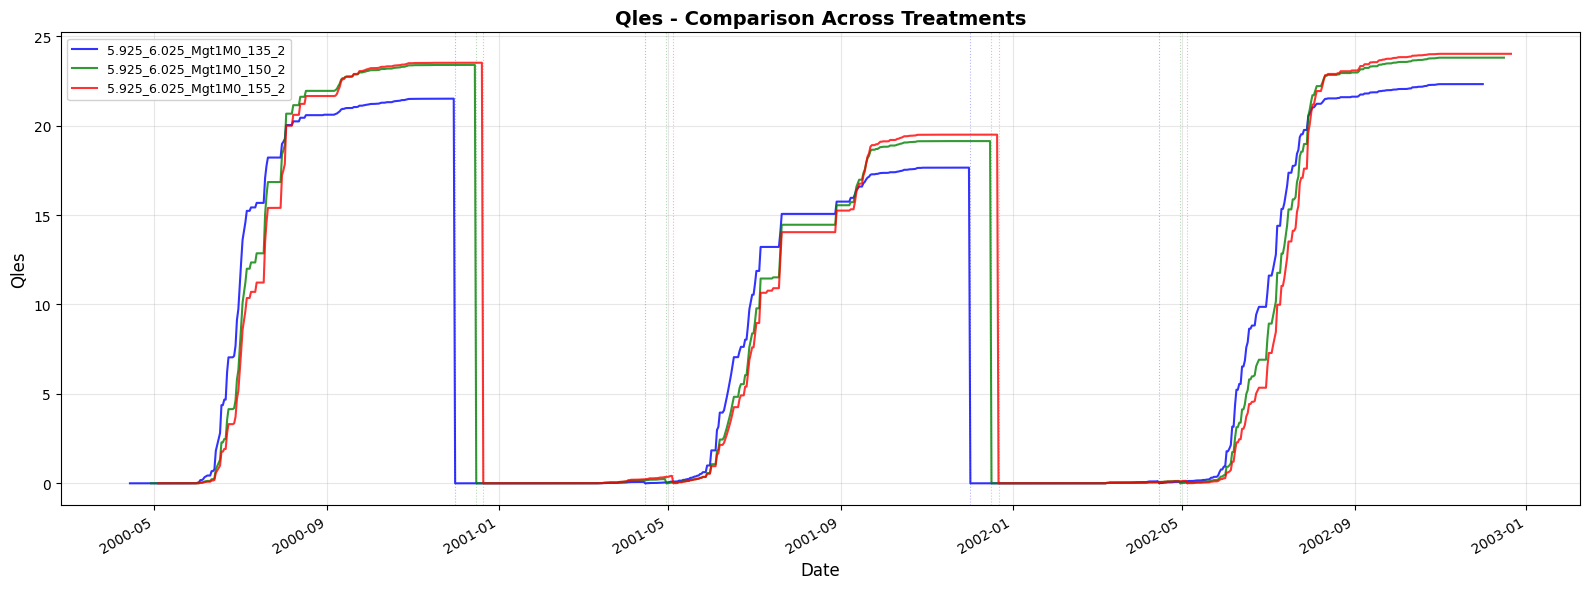


Plotting: HR(1) - All Treatments Comparison
  ✓ 5.925_6.025_Mgt1M0_135_2: 962 days, 4 transitions
  ✓ 5.925_6.025_Mgt1M0_150_2: 962 days, 4 transitions
  ✓ 5.925_6.025_Mgt1M0_155_2: 962 days, 4 transitions


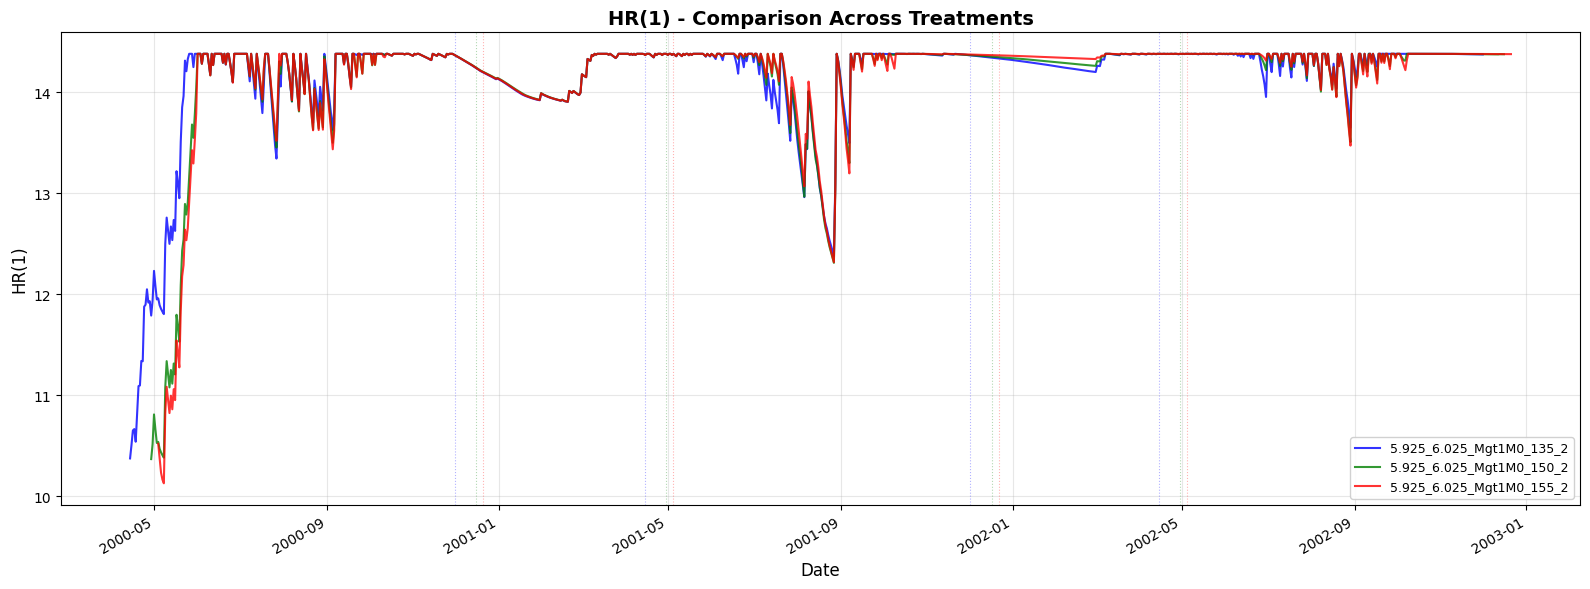


Plotting: Chumt - All Treatments Comparison
  ✓ 5.925_6.025_Mgt1M0_135_2: 962 days, 4 transitions
  ✓ 5.925_6.025_Mgt1M0_150_2: 962 days, 4 transitions
  ✓ 5.925_6.025_Mgt1M0_155_2: 962 days, 4 transitions


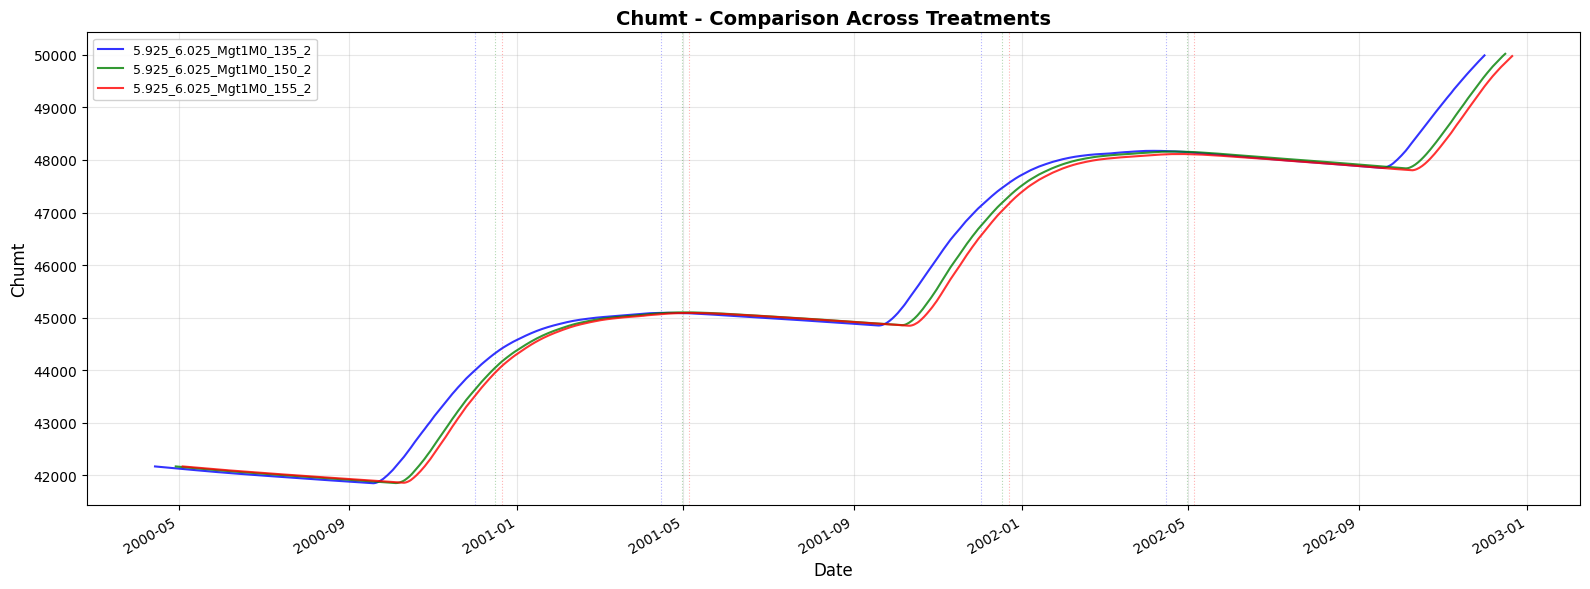


TREATMENT COMPARISON COMPLETE

Variables compared: resmes, azomes, Qles, HR(1), Chumt
Number of treatments: 3


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from collections import defaultdict

# ========================================
# CONFIGURATION: Variables to compare across treatments
# ========================================
VARIABLES_TO_COMPARE = ['resmes', 'azomes', 'Qles', 'HR(1)', 'Chumt']

# Number of treatments to compare (set to None for all)
MAX_TREATMENTS_COMPARE = 5

# Color palette for treatments
TREATMENT_COLORS = ['blue', 'green', 'red', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan', 'magenta']

# ========================================
# Collect data for all treatments
# ========================================

all_treatments_data = {}

treatment_limit = MAX_TREATMENTS_COMPARE if MAX_TREATMENTS_COMPARE else len(treatment_groups)

for treatment_idx, (treatment_pattern, sim_dirs) in enumerate(list(treatment_groups.items())[:treatment_limit], start=1):
    
    # Sort directories chronologically
    def extract_year(sim_dir):
        parts = sim_dir.name.split('_')
        if len(parts) >= 3:
            try:
                return int(parts[2])
            except ValueError:
                pass
        return 0
    
    sim_dirs_sorted = sorted(sim_dirs, key=extract_year)
    
    # Collect all mod_s*.sti files
    treatment_dfs = []
    for sim_dir in sim_dirs_sorted:
        for sti_file in sorted(sim_dir.glob("mod_s*.sti")):
            try:
                df = pd.read_csv(sti_file, sep=";")
                if not df.empty:
                    df['sim_dir'] = sim_dir.name
                    df['is_intercrop'] = '__intercrop__' in sim_dir.name
                    treatment_dfs.append(df)
            except Exception as e:
                pass
    
    if not treatment_dfs:
        continue
    
    # Combine all outputs
    combined_df = pd.concat(treatment_dfs, ignore_index=True)
    
    # Create datetime
    if all(col in combined_df.columns for col in ['ian', 'mo', 'jo']):
        combined_df['date'] = pd.to_datetime(
            combined_df[['ian', 'mo', 'jo']].rename(columns={'ian': 'year', 'mo': 'month', 'jo': 'day'})
        )
    else:
        combined_df['date'] = pd.date_range(start='2000-01-01', periods=len(combined_df), freq='D')
    
    # Store treatment data
    all_treatments_data[treatment_pattern] = combined_df

print(f"Collected data for {len(all_treatments_data)} treatments")

# ========================================
# Plot: One variable, all treatments
# ========================================

for var_name in VARIABLES_TO_COMPARE:
    
    # Check if variable exists in at least one treatment
    has_var = any(var_name in df.columns for df in all_treatments_data.values())
    
    if not has_var:
        print(f"⚠ Variable '{var_name}' not found in any treatment, skipping...")
        continue
    
    print(f"\n{'='*60}")
    print(f"Plotting: {var_name} - All Treatments Comparison")
    print(f"{'='*60}")
    
    fig, ax = plt.subplots(1, 1, figsize=(16, 6))
    
    # Plot each treatment
    for idx, (treatment_pattern, df) in enumerate(all_treatments_data.items()):
        
        if var_name not in df.columns:
            print(f"  ⚠ {treatment_pattern}: '{var_name}' not available")
            continue
        
        color = TREATMENT_COLORS[idx % len(TREATMENT_COLORS)]
        
        # Plot treatment curve
        ax.plot(df['date'], df[var_name], 
                color=color, linewidth=1.5, alpha=0.8, 
                label=f'{treatment_pattern}')
        
        # Detect transitions for this treatment
        transitions = []
        prev_dir = None
        for _, row in df.iterrows():
            if prev_dir is not None and row['sim_dir'] != prev_dir:
                transitions.append(row['date'])
            prev_dir = row['sim_dir']
        
        # Add subtle vertical lines for transitions (same color as curve)
        for trans_date in transitions:
            ax.axvline(trans_date, color=color, linestyle=':', alpha=0.3, linewidth=0.8)
        
        print(f"  ✓ {treatment_pattern}: {len(df)} days, {len(transitions)} transitions")
    
    # Configure plot
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel(var_name, fontsize=12)
    ax.set_title(f'{var_name} - Comparison Across Treatments', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9, framealpha=0.9)
    
    # Format x-axis
    fig.autofmt_xdate()
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("TREATMENT COMPARISON COMPLETE")
print("="*60)
print(f"\nVariables compared: {', '.join(VARIABLES_TO_COMPARE)}")
print(f"Number of treatments: {len(all_treatments_data)}")